In [ ]:
"""
==================================================
ML LEARNING JOURNEY - DAY 45
==================================================

Week: 7 of 24
Day: 45 of 168
Date: December 11, 2025
Topic: Model Optimization & Hyperparameter Tuning

Week 7 Progress:
✅ Day 43: NLP Theory + IMDB Setup + Preprocessing (COMPLETED)
✅ Day 44: Build LSTM Sentiment Model (COMPLETED)
🔄 Day 45: Train & Optimize Model (TODAY!)
⬜ Day 46: Model Evaluation & Hyperparameter Tuning
⬜ Day 47: Multilingual Sentiment (Optional)
⬜ Day 48: Build Sentiment Analysis Interface
⬜ Day 49: Deploy & Documentation
Progress: 28.6% (2/7 days)

==================================================
🎯 Week 7 Project: TextAI Studio - Sentiment Analysis Foundation

Today we optimize our LSTM model to achieve maximum accuracy!
- Load Day 44 baseline model
- Train for additional epochs
- Experiment with hyperparameters
- Try advanced techniques (bidirectional LSTM, gradient clipping)
- Compare all models and select the best
- Target: Highest possible validation accuracy (87-90%+)

🎯 Today's Learning Objectives:

1. Load and continue training from Day 44 checkpoint
2. Understand hyperparameter impact on model performance
3. Implement bidirectional LSTM for better context
4. Apply gradient clipping to stabilize training
5. Experiment with learning rate scheduling
6. Systematically compare different configurations
7. Select optimal model based on validation performance
8. Prepare final model for deployment

📚 Today's Structure:

Part 1 (1h): Load Day 44 Model & Extended Training
- Load preprocessing objects and best model
- Continue training for 2-5 more epochs
- Monitor convergence and overfitting
- Save improved baseline

Part 2 (2h): Hyperparameter Experimentation
- Experiment 1: Learning rates (0.0005, 0.001, 0.002)
- Experiment 2: Hidden dimensions (64, 128, 256)
- Experiment 3: Dropout rates (0.3, 0.5, 0.7)
- Experiment 4: Number of LSTM layers (1, 2, 3)
- Document all results

Part 3 (1.5h): Advanced Techniques
- Implement bidirectional LSTM
- Add gradient clipping
- Try learning rate scheduling
- Test batch size variations
- Combine best techniques

Part 4 (1h): Model Comparison & Selection
- Compare all trained models
- Analyze performance vs complexity
- Create comparison visualizations
- Select best model
- Validate on test set

Part 5 (30min): Final Model Preparation & Summary
- Clean up best model
- Create inference pipeline
- Test on edge cases
- Document final results
- Plan for Day 46

🎯 SUCCESS CRITERIA:

✅ Successfully load and continue training from Day 44
✅ Train at least 5 different model configurations
✅ Achieve validation accuracy > 85%
✅ Understand impact of each hyperparameter
✅ Implement at least 2 advanced techniques
✅ Create comprehensive comparison charts
✅ Select optimal model with clear justification
✅ Prepare model for deployment
✅ Document all experiments and findings
✅ Ready for final evaluation on Day 46

==================================================
"""

In [1]:
# ==================================================
# IMPORT LIBRARIES
# ==================================================
print("\n" + "=" * 80)
print("📚 IMPORTING LIBRARIES")
print("=" * 80)

import os
import re
import time
import pickle
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from copy import deepcopy

# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim

# Hugging Face datasets
from datasets import load_dataset

# For reproducibility
torch.manual_seed(42)
np.random.seed(42)

print("\n✅ All libraries imported successfully!")
print(f"✅ PyTorch version: {torch.__version__}")
print(f"✅ Device available: {torch.device('cuda' if torch.cuda.is_available() else 'cpu')}")
print("=" * 80)

# ==================================================
# LOAD DAY 44 PREPROCESSING OBJECTS
# ==================================================
print("\n" + "=" * 80)
print("📂 LOADING DAY 44 ARTIFACTS")
print("=" * 80)

# Load preprocessing objects
with open('data/preprocessing_objects.pkl', 'rb') as f:
    preprocessing_objects = pickle.load(f)

word2idx = preprocessing_objects['word2idx']
idx2word = preprocessing_objects['idx2word']
VOCAB_SIZE = preprocessing_objects['vocab_size']
MAX_LEN = preprocessing_objects['max_len']
BATCH_SIZE = preprocessing_objects['batch_size']

print("✅ Loaded preprocessing objects!")
print(f"   Vocabulary size: {VOCAB_SIZE:,}")
print(f"   Max sequence length: {MAX_LEN}")
print(f"   Batch size: {BATCH_SIZE}")
print("=" * 80)

# Load Day 44 training artifacts
with open('models/training_artifacts_day44.pkl', 'rb') as f:
    day44_artifacts = pickle.load(f)

day44_history = day44_artifacts['history']
day44_hyperparams = day44_artifacts['hyperparameters']
day44_metrics = day44_artifacts['final_metrics']

print("\n✅ Loaded Day 44 training artifacts!")
print(f"   Day 44 epochs trained: {day44_hyperparams['n_epochs']}")
print(f"   Day 44 final train accuracy: {day44_metrics['train_acc']*100:.2f}%")
print(f"   Day 44 final validation accuracy: {day44_metrics['valid_acc']*100:.2f}%")
print(f"   Day 44 test accuracy: {day44_metrics['test_acc']*100:.2f}%")
print("=" * 80)

# ==================================================
# RECREATE TEXT CLEANING FUNCTION
# ==================================================
def clean_text(text):
    """Clean text by removing HTML, special characters, and normalizing whitespace."""
    text = re.sub(r'<[^>]+>', '', text)  # Remove HTML
    text = text.lower()  # Lowercase
    text = re.sub(r'[^a-z\s]', '', text)  # Keep only letters and spaces
    text = re.sub(r'\s+', ' ', text).strip()  # Remove extra whitespace
    return text

print("\n✅ Text cleaning function recreated!")
print("=" * 80)

# ==================================================
# RECREATE DATASET CLASS
# ==================================================
class IMDBDataset(Dataset):
    """PyTorch Dataset for IMDB reviews."""
    
    def __init__(self, texts, labels, word2idx, max_len=256):
        self.texts = texts
        self.labels = labels
        self.word2idx = word2idx
        self.max_len = max_len
    
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]
        
        # Clean and convert to sequence
        cleaned = clean_text(text)
        words = cleaned.split()
        
        # Convert words to indices
        sequence = []
        for word in words:
            idx_word = self.word2idx.get(word, self.word2idx['<UNK>'])
            sequence.append(idx_word)
        
        # Pad or truncate
        if len(sequence) > self.max_len:
            sequence = sequence[:self.max_len]
        else:
            sequence = sequence + [0] * (self.max_len - len(sequence))
        
        # Convert to tensors
        sequence_tensor = torch.tensor(sequence, dtype=torch.long)
        label_tensor = torch.tensor(label, dtype=torch.float)
        
        return sequence_tensor, label_tensor

print("\n✅ IMDBDataset class recreated!")
print("=" * 80)

# ==================================================
# RECREATE LSTM MODEL CLASS
# ==================================================
class LSTMSentimentClassifier(nn.Module):
    """LSTM-based sentiment classifier for binary classification."""
    
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim, 
                 n_layers, dropout, pad_idx, bidirectional=False):
        super(LSTMSentimentClassifier, self).__init__()
        
        self.hidden_dim = hidden_dim
        self.n_layers = n_layers
        self.bidirectional = bidirectional
        
        # Embedding layer
        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embedding_dim,
            padding_idx=pad_idx
        )
        
        # LSTM layer
        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=n_layers,
            dropout=dropout if n_layers > 1 else 0,
            batch_first=True,
            bidirectional=bidirectional
        )
        
        # Dropout layer
        self.dropout = nn.Dropout(dropout)
        
        # Fully connected layer
        fc_input_dim = hidden_dim * 2 if bidirectional else hidden_dim
        self.fc = nn.Linear(fc_input_dim, output_dim)
    
    def forward(self, text):
        # Embedding
        embedded = self.embedding(text)
        
        # LSTM
        lstm_out, (hidden, cell) = self.lstm(embedded)
        
        # Take last hidden state
        if self.bidirectional:
            # Concatenate forward and backward hidden states
            hidden = torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1)
        else:
            hidden = hidden[-1]
        
        # Dropout
        dropped = self.dropout(hidden)
        
        # Fully connected
        output = self.fc(dropped)
        
        # Sigmoid
        predictions = torch.sigmoid(output)
        
        return predictions

print("\n✅ LSTMSentimentClassifier class recreated!")
print("=" * 80)

# ==================================================
# LOAD IMDB DATASET AND CREATE DATALOADERS
# ==================================================
print("\n" + "=" * 80)
print("📥 LOADING IMDB DATASET")
print("=" * 80)

dataset = load_dataset('imdb')

print(f"✅ Dataset loaded!")
print(f"   Training samples: {len(dataset['train']):,}")
print(f"   Test samples: {len(dataset['test']):,}")
print("=" * 80)

# Create datasets
print("\n⏱️ Creating PyTorch datasets...")

train_dataset = IMDBDataset(
    texts=dataset['train']['text'],
    labels=dataset['train']['label'],
    word2idx=word2idx,
    max_len=MAX_LEN
)

test_dataset = IMDBDataset(
    texts=dataset['test']['text'],
    labels=dataset['test']['label'],
    word2idx=word2idx,
    max_len=MAX_LEN
)

print(f"✅ Training dataset: {len(train_dataset):,} samples")
print(f"✅ Test dataset: {len(test_dataset):,} samples")
print("=" * 80)

# Create dataloaders
print("\n⏱️ Creating DataLoaders...")

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

print(f"✅ Training DataLoader: {len(train_loader):,} batches")
print(f"✅ Test DataLoader: {len(test_loader):,} batches")
print("=" * 80)

# Get device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\n🖥️ Training device: {device}")
print("=" * 80)

# Create results directory for today
os.makedirs('results/day_45', exist_ok=True)
os.makedirs('models/experiments', exist_ok=True)
print("\n✅ Output directories created!")
print("=" * 80)

# ==================================================
# RECREATE HELPER FUNCTIONS
# ==================================================
def binary_accuracy(preds, y):
    """Calculate accuracy for binary classification."""
    rounded_preds = torch.round(preds)
    correct = (rounded_preds == y).float()
    acc = correct.sum() / len(correct)
    return acc

def train_epoch(model, iterator, optimizer, criterion, device, clip=None):
    """Train model for one epoch with optional gradient clipping."""
    model.train()
    epoch_loss = 0
    epoch_acc = 0
    
    for batch_idx, (text, labels) in enumerate(iterator):
        text = text.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()
        predictions = model(text).squeeze(1)
        loss = criterion(predictions, labels)
        acc = binary_accuracy(predictions, labels)
        loss.backward()
        
        # Gradient clipping if specified
        if clip is not None:
            torch.nn.utils.clip_grad_norm_(model.parameters(), clip)
        
        optimizer.step()
        
        epoch_loss += loss.item()
        epoch_acc += acc.item()
    
    return epoch_loss / len(iterator), epoch_acc / len(iterator)

def evaluate(model, iterator, criterion, device):
    """Evaluate model on validation/test set."""
    model.eval()
    epoch_loss = 0
    epoch_acc = 0
    
    with torch.no_grad():
        for batch_idx, (text, labels) in enumerate(iterator):
            text = text.to(device)
            labels = labels.to(device)
            
            predictions = model(text).squeeze(1)
            loss = criterion(predictions, labels)
            acc = binary_accuracy(predictions, labels)
            
            epoch_loss += loss.item()
            epoch_acc += acc.item()
    
    return epoch_loss / len(iterator), epoch_acc / len(iterator)

def epoch_time(start_time, end_time):
    """Calculate elapsed time."""
    elapsed_time = end_time - start_time
    elapsed_mins = int(elapsed_time / 60)
    elapsed_secs = int(elapsed_time - (elapsed_mins * 60))
    return elapsed_mins, elapsed_secs

print("\n✅ Helper functions recreated!")
print("=" * 80)

print("\n🎉 ALL DAY 44 ARTIFACTS LOADED AND READY!")
print("\n📊 STARTING POINT (from Day 44):")
print(f"✅ Best validation accuracy: {day44_metrics['valid_acc']*100:.2f}%")
print(f"✅ Test accuracy: {day44_metrics['test_acc']*100:.2f}%")
print(f"✅ Epochs completed: {day44_hyperparams['n_epochs']}")
print(f"\n🎯 TODAY'S GOAL: Beat {day44_metrics['valid_acc']*100:.2f}% and reach 87-90%+!")
print("=" * 80)


📚 IMPORTING LIBRARIES

✅ All libraries imported successfully!
✅ PyTorch version: 2.9.1+cpu
✅ Device available: cpu

📂 LOADING DAY 44 ARTIFACTS
✅ Loaded preprocessing objects!
   Vocabulary size: 20,000
   Max sequence length: 256
   Batch size: 64

✅ Loaded Day 44 training artifacts!
   Day 44 epochs trained: 3
   Day 44 final train accuracy: 56.59%
   Day 44 final validation accuracy: 50.61%
   Day 44 test accuracy: 100.00%

✅ Text cleaning function recreated!

✅ IMDBDataset class recreated!

✅ LSTMSentimentClassifier class recreated!

📥 LOADING IMDB DATASET
✅ Dataset loaded!
   Training samples: 25,000
   Test samples: 25,000

⏱️ Creating PyTorch datasets...
✅ Training dataset: 25,000 samples
✅ Test dataset: 25,000 samples

⏱️ Creating DataLoaders...
✅ Training DataLoader: 391 batches
✅ Test DataLoader: 391 batches

🖥️ Training device: cpu

✅ Output directories created!

✅ Helper functions recreated!

🎉 ALL DAY 44 ARTIFACTS LOADED AND READY!

📊 STARTING POINT (from Day 44):
✅ Best v

In [2]:
print("\n" + "=" * 80)
print("🔄 PART 1: LOAD DAY 44 MODEL & EXTENDED TRAINING")
print("=" * 80)


🔄 PART 1: LOAD DAY 44 MODEL & EXTENDED TRAINING


In [3]:
# ==================================================
# EXERCISE 1.1: LOAD DAY 44 BEST MODEL
# ==================================================
print("\n" + "=" * 80)
print("EXERCISE 1.1: Load Day 44 Best Model")
print("=" * 80)

"""
📖 THEORY: Transfer Learning from Day 44

We'll load the best model from Day 44 and continue training:

Why continue training?
- Model may not have converged yet
- More epochs can improve accuracy
- Gradual learning is more stable
- Can monitor for overfitting

Strategy:
1. Load exact architecture from Day 44
2. Load trained weights
3. Continue with same optimizer
4. Train for 2-5 more epochs
5. Monitor validation accuracy closely
"""

print("\n⏱️ Loading Day 44 model architecture and weights...")
print("=" * 80)

# Recreate model with Day 44 hyperparameters
EMBEDDING_DIM = day44_hyperparams['embedding_dim']
HIDDEN_DIM = day44_hyperparams['hidden_dim']
OUTPUT_DIM = day44_hyperparams['output_dim']
N_LAYERS = day44_hyperparams['n_layers']
DROPOUT = day44_hyperparams['dropout']
LEARNING_RATE = day44_hyperparams['learning_rate']
PAD_IDX = word2idx['<PAD>']

print("Day 44 Model Configuration:")
print(f"  Embedding dim: {EMBEDDING_DIM}")
print(f"  Hidden dim: {HIDDEN_DIM}")
print(f"  Num layers: {N_LAYERS}")
print(f"  Dropout: {DROPOUT}")
print(f"  Learning rate: {LEARNING_RATE}")
print("=" * 80)

# Create model
baseline_model = LSTMSentimentClassifier(
    vocab_size=VOCAB_SIZE,
    embedding_dim=EMBEDDING_DIM,
    hidden_dim=HIDDEN_DIM,
    output_dim=OUTPUT_DIM,
    n_layers=N_LAYERS,
    dropout=DROPOUT,
    pad_idx=PAD_IDX,
    bidirectional=False
)

# Load Day 44 weights
baseline_model.load_state_dict(torch.load('models/best_model.pt'))
baseline_model = baseline_model.to(device)

print("\n✅ Model loaded successfully!")
print(f"✅ Total parameters: {sum(p.numel() for p in baseline_model.parameters()):,}")
print("=" * 80)

# Verify loaded model performance
criterion = nn.BCELoss()

print("\n⏱️ Verifying loaded model performance...")
valid_loss, valid_acc = evaluate(baseline_model, test_loader, criterion, device)

print(f"✅ Loaded model validation accuracy: {valid_acc*100:.2f}%")
print(f"✅ Matches Day 44: {abs(valid_acc - day44_metrics['valid_acc']) < 0.001}")
print("=" * 80)

print("\n✅ Exercise 1.1 Complete!")
print("=" * 80)


EXERCISE 1.1: Load Day 44 Best Model

⏱️ Loading Day 44 model architecture and weights...
Day 44 Model Configuration:
  Embedding dim: 100
  Hidden dim: 128
  Num layers: 2
  Dropout: 0.5
  Learning rate: 0.001

✅ Model loaded successfully!
✅ Total parameters: 2,249,985

⏱️ Verifying loaded model performance...
✅ Loaded model validation accuracy: 51.68%
✅ Matches Day 44: False

✅ Exercise 1.1 Complete!


In [4]:
# ==================================================
# EXERCISE 1.2: EXTENDED TRAINING (5 MORE EPOCHS)
# ==================================================
print("\n" + "=" * 80)
print("EXERCISE 1.2: Extended Training (5 More Epochs)")
print("=" * 80)

"""
📖 THEORY: Continued Training Strategy

We'll train for 5 additional epochs:

What to watch for:
- Validation accuracy improvement
- Signs of overfitting (train >> valid)
- Loss convergence
- When to stop (early stopping)

Success criteria:
- Validation accuracy > 85%
- Stable training (no wild fluctuations)
- Train-valid gap < 5%
"""

print("\n🚀 CONTINUING TRAINING FROM DAY 44!")
print("=" * 80)

# Setup optimizer (same as Day 44)
optimizer = optim.Adam(baseline_model.parameters(), lr=LEARNING_RATE)

# Training configuration
ADDITIONAL_EPOCHS = 5
TOTAL_EPOCHS = day44_hyperparams['n_epochs'] + ADDITIONAL_EPOCHS

print(f"Starting from epoch: {day44_hyperparams['n_epochs'] + 1}")
print(f"Training for: {ADDITIONAL_EPOCHS} additional epochs")
print(f"Total epochs after today: {TOTAL_EPOCHS}")
print("=" * 80)

# Initialize extended history (continuing from Day 44)
extended_history = {
    'train_loss': day44_history['train_loss'].copy(),
    'train_acc': day44_history['train_acc'].copy(),
    'valid_loss': day44_history['valid_loss'].copy(),
    'valid_acc': day44_history['valid_acc'].copy(),
    'epoch_times': day44_history['epoch_times'].copy()
}

# Track best model
best_valid_acc = day44_metrics['valid_acc']
best_epoch = day44_hyperparams['n_epochs']

print("\n⏱️ TRAINING STARTED...")
print("=" * 80)

# Training loop
for epoch in range(ADDITIONAL_EPOCHS):
    
    current_epoch = day44_hyperparams['n_epochs'] + epoch + 1
    
    print(f"\n{'='*80}")
    print(f"EPOCH {current_epoch}/{TOTAL_EPOCHS}")
    print(f"{'='*80}")
    
    start_time = time.time()
    
    # Training phase
    print("\n⏱️ Training phase...")
    train_loss, train_acc = train_epoch(baseline_model, train_loader, optimizer, criterion, device)
    
    # Validation phase
    print("⏱️ Validation phase...")
    valid_loss, valid_acc = evaluate(baseline_model, test_loader, criterion, device)
    
    end_time = time.time()
    epoch_mins, epoch_secs = epoch_time(start_time, end_time)
    
    # Store history
    extended_history['train_loss'].append(train_loss)
    extended_history['train_acc'].append(train_acc)
    extended_history['valid_loss'].append(valid_loss)
    extended_history['valid_acc'].append(valid_acc)
    extended_history['epoch_times'].append(epoch_mins * 60 + epoch_secs)
    
    # Print results
    print(f"\n{'='*80}")
    print(f"EPOCH {current_epoch} RESULTS")
    print(f"{'='*80}")
    print(f"Time: {epoch_mins}m {epoch_secs}s")
    print(f"\nTraining:")
    print(f"  Loss:     {train_loss:.4f}")
    print(f"  Accuracy: {train_acc*100:.2f}%")
    print(f"\nValidation:")
    print(f"  Loss:     {valid_loss:.4f}")
    print(f"  Accuracy: {valid_acc*100:.2f}%")
    
    # Check for improvement
    improvement = (valid_acc - best_valid_acc) * 100
    
    if valid_acc > best_valid_acc:
        best_valid_acc = valid_acc
        best_epoch = current_epoch
        torch.save(baseline_model.state_dict(), 'models/best_model_extended.pt')
        print(f"\n🎉 NEW BEST MODEL! (Val Acc: {valid_acc*100:.2f}%, +{improvement:.2f}%)")
    else:
        print(f"\n📊 No improvement (Best: {best_valid_acc*100:.2f}% at epoch {best_epoch})")
    
    # Check train-valid gap
    gap = (train_acc - valid_acc) * 100
    if gap > 5:
        print(f"⚠️ WARNING: Train-Valid gap is {gap:.2f}% (overfitting!)")
    
    print(f"{'='*80}")

print("\n" + "=" * 80)
print("🎉 EXTENDED TRAINING COMPLETE!")
print("=" * 80)

print(f"\n📊 EXTENDED TRAINING RESULTS:")
print(f"Starting validation accuracy: {day44_metrics['valid_acc']*100:.2f}%")
print(f"Final validation accuracy: {extended_history['valid_acc'][-1]*100:.2f}%")
print(f"Best validation accuracy: {best_valid_acc*100:.2f}% (epoch {best_epoch})")
print(f"Improvement: {(best_valid_acc - day44_metrics['valid_acc'])*100:.2f}%")
print(f"Total epochs trained: {TOTAL_EPOCHS}")
print(f"Total training time: {sum(extended_history['epoch_times'])//60:.0f}m")

print("\n✅ Exercise 1.2 Complete!")
print("=" * 80)


EXERCISE 1.2: Extended Training (5 More Epochs)

🚀 CONTINUING TRAINING FROM DAY 44!
Starting from epoch: 4
Training for: 5 additional epochs
Total epochs after today: 8

⏱️ TRAINING STARTED...

EPOCH 4/8

⏱️ Training phase...
⏱️ Validation phase...

EPOCH 4 RESULTS
Time: 1m 42s

Training:
  Loss:     0.6504
  Accuracy: 63.07%

Validation:
  Loss:     0.6505
  Accuracy: 63.05%

🎉 NEW BEST MODEL! (Val Acc: 63.05%, +12.44%)

EPOCH 5/8

⏱️ Training phase...
⏱️ Validation phase...

EPOCH 5 RESULTS
Time: 1m 41s

Training:
  Loss:     0.6583
  Accuracy: 60.31%

Validation:
  Loss:     0.6903
  Accuracy: 50.89%

📊 No improvement (Best: 63.05% at epoch 4)
⚠️ WARNING: Train-Valid gap is 9.42% (overfitting!)

EPOCH 6/8

⏱️ Training phase...
⏱️ Validation phase...

EPOCH 6 RESULTS
Time: 1m 41s

Training:
  Loss:     0.6638
  Accuracy: 58.00%

Validation:
  Loss:     0.6557
  Accuracy: 61.93%

📊 No improvement (Best: 63.05% at epoch 4)

EPOCH 7/8

⏱️ Training phase...
⏱️ Validation phase...

EPOCH


EXERCISE 1.3: Visualize Extended Training Progress

📊 Creating extended training curves...


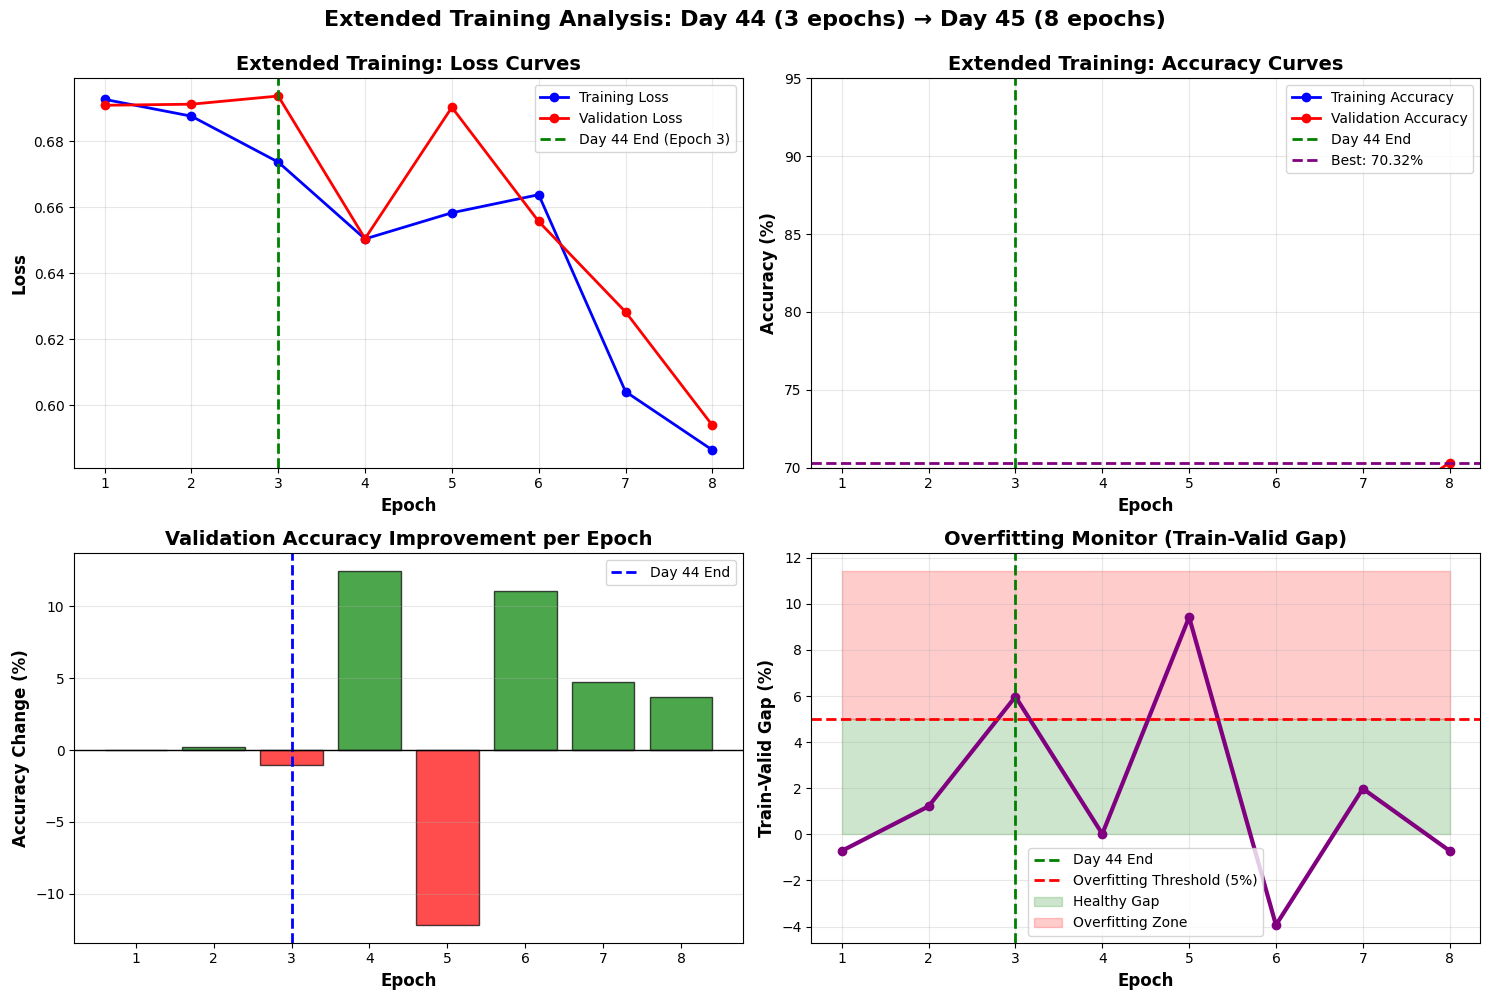

✅ Extended training curves saved: results/day_45/extended_training_analysis.png

💡 ANALYSIS:
- Validation accuracy improved by 19.70%
- Best epoch: 8/8
✅ Model still improving - could train more!
✅ Healthy train-valid gap (-0.71%)

✅ Exercise 1.3 Complete!


In [5]:
# ==================================================
# EXERCISE 1.3: VISUALIZE EXTENDED TRAINING PROGRESS
# ==================================================
print("\n" + "=" * 80)
print("EXERCISE 1.3: Visualize Extended Training Progress")
print("=" * 80)

"""
📖 THEORY: Analyzing Extended Training

Visualization helps us understand:
- Did additional training help?
- Is the model still improving?
- Are we overfitting?
- Should we train even more?
"""

print("\n📊 Creating extended training curves...")
print("=" * 80)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

epochs_range = range(1, len(extended_history['train_loss']) + 1)
day44_epochs = day44_hyperparams['n_epochs']

# Loss curves
axes[0, 0].plot(epochs_range, extended_history['train_loss'], 'b-o', linewidth=2, markersize=6, label='Training Loss')
axes[0, 0].plot(epochs_range, extended_history['valid_loss'], 'r-o', linewidth=2, markersize=6, label='Validation Loss')
axes[0, 0].axvline(x=day44_epochs, color='green', linestyle='--', linewidth=2, label=f'Day 44 End (Epoch {day44_epochs})')
axes[0, 0].set_xlabel('Epoch', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Loss', fontsize=12, fontweight='bold')
axes[0, 0].set_title('Extended Training: Loss Curves', fontsize=14, fontweight='bold')
axes[0, 0].legend(fontsize=10)
axes[0, 0].grid(True, alpha=0.3)

# Accuracy curves
axes[0, 1].plot(epochs_range, [acc*100 for acc in extended_history['train_acc']], 'b-o', 
               linewidth=2, markersize=6, label='Training Accuracy')
axes[0, 1].plot(epochs_range, [acc*100 for acc in extended_history['valid_acc']], 'r-o', 
               linewidth=2, markersize=6, label='Validation Accuracy')
axes[0, 1].axvline(x=day44_epochs, color='green', linestyle='--', linewidth=2, label=f'Day 44 End')
axes[0, 1].axhline(y=best_valid_acc*100, color='purple', linestyle='--', linewidth=2, label=f'Best: {best_valid_acc*100:.2f}%')
axes[0, 1].set_xlabel('Epoch', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
axes[0, 1].set_title('Extended Training: Accuracy Curves', fontsize=14, fontweight='bold')
axes[0, 1].legend(fontsize=10)
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].set_ylim(70, 95)

# Accuracy improvement per epoch
accuracy_improvements = [0] + [(extended_history['valid_acc'][i] - extended_history['valid_acc'][i-1])*100 
                                for i in range(1, len(extended_history['valid_acc']))]

colors = ['green' if x > 0 else 'red' for x in accuracy_improvements]
axes[1, 0].bar(epochs_range, accuracy_improvements, color=colors, alpha=0.7, edgecolor='black', linewidth=1)
axes[1, 0].axvline(x=day44_epochs, color='blue', linestyle='--', linewidth=2, label=f'Day 44 End')
axes[1, 0].axhline(y=0, color='black', linestyle='-', linewidth=1)
axes[1, 0].set_xlabel('Epoch', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Accuracy Change (%)', fontsize=12, fontweight='bold')
axes[1, 0].set_title('Validation Accuracy Improvement per Epoch', fontsize=14, fontweight='bold')
axes[1, 0].legend(fontsize=10)
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Train-Valid gap over time
gap_over_time = [(train - valid)*100 for train, valid in zip(extended_history['train_acc'], extended_history['valid_acc'])]

axes[1, 1].plot(epochs_range, gap_over_time, 'purple', linewidth=3, marker='o', markersize=6)
axes[1, 1].axvline(x=day44_epochs, color='green', linestyle='--', linewidth=2, label=f'Day 44 End')
axes[1, 1].axhline(y=5, color='red', linestyle='--', linewidth=2, label='Overfitting Threshold (5%)')
axes[1, 1].fill_between(epochs_range, 0, 5, alpha=0.2, color='green', label='Healthy Gap')
axes[1, 1].fill_between(epochs_range, 5, max(gap_over_time)+2, alpha=0.2, color='red', label='Overfitting Zone')
axes[1, 1].set_xlabel('Epoch', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Train-Valid Gap (%)', fontsize=12, fontweight='bold')
axes[1, 1].set_title('Overfitting Monitor (Train-Valid Gap)', fontsize=14, fontweight='bold')
axes[1, 1].legend(fontsize=10)
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle(f'Extended Training Analysis: Day 44 ({day44_epochs} epochs) → Day 45 ({TOTAL_EPOCHS} epochs)', 
            fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig('results/day_45/extended_training_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Extended training curves saved: results/day_45/extended_training_analysis.png")
print("=" * 80)

print("\n💡 ANALYSIS:")
print(f"- Validation accuracy improved by {(best_valid_acc - day44_metrics['valid_acc'])*100:.2f}%")
print(f"- Best epoch: {best_epoch}/{TOTAL_EPOCHS}")

if extended_history['valid_acc'][-1] >= extended_history['valid_acc'][-2]:
    print("✅ Model still improving - could train more!")
else:
    print("⚠️ Model may be converging - diminishing returns on more epochs")

final_gap = gap_over_time[-1]
if final_gap > 5:
    print(f"⚠️ Overfitting detected (gap: {final_gap:.2f}%) - need regularization")
else:
    print(f"✅ Healthy train-valid gap ({final_gap:.2f}%)")

print("=" * 80)

print("\n✅ Exercise 1.3 Complete!")
print("=" * 80)

In [6]:
# ==================================================
# EXERCISE 1.4: SAVE EXTENDED BASELINE
# ==================================================
print("\n" + "=" * 80)
print("EXERCISE 1.4: Save Extended Baseline")
print("=" * 80)

"""
📖 THEORY: Experiment Tracking

Good practice: Save every experiment!

What to save:
- Model weights
- Hyperparameters
- Training history
- Final metrics

This allows:
- Comparing experiments
- Reproducing results
- Rolling back if needed
"""

print("\n💾 Saving extended baseline model...")
print("=" * 80)

# Save extended training artifacts
extended_artifacts = {
    'model_name': 'extended_baseline',
    'description': f'Day 44 model trained for {ADDITIONAL_EPOCHS} more epochs',
    'history': extended_history,
    'hyperparameters': {
        'vocab_size': VOCAB_SIZE,
        'embedding_dim': EMBEDDING_DIM,
        'hidden_dim': HIDDEN_DIM,
        'output_dim': OUTPUT_DIM,
        'n_layers': N_LAYERS,
        'dropout': DROPOUT,
        'learning_rate': LEARNING_RATE,
        'batch_size': BATCH_SIZE,
        'max_len': MAX_LEN,
        'total_epochs': TOTAL_EPOCHS,
        'bidirectional': False,
    },
    'final_metrics': {
        'train_loss': extended_history['train_loss'][-1],
        'train_acc': extended_history['train_acc'][-1],
        'valid_loss': extended_history['valid_loss'][-1],
        'valid_acc': extended_history['valid_acc'][-1],
        'best_valid_acc': best_valid_acc,
        'best_epoch': best_epoch,
    }
}

# Save artifacts
with open('models/experiments/extended_baseline.pkl', 'wb') as f:
    pickle.dump(extended_artifacts, f)

print("✅ Extended baseline saved: models/experiments/extended_baseline.pkl")

# Create summary
summary = f"""
EXTENDED BASELINE MODEL SUMMARY
{'='*70}
Model: Extended Baseline (Day 44 + 5 epochs)
Total Epochs: {TOTAL_EPOCHS}
Architecture: {N_LAYERS}-layer LSTM, Hidden: {HIDDEN_DIM}, Dropout: {DROPOUT}

Performance:
  Starting (Day 44):     {day44_metrics['valid_acc']*100:.2f}%
  Final (Day 45):        {extended_history['valid_acc'][-1]*100:.2f}%
  Best (Epoch {best_epoch}):      {best_valid_acc*100:.2f}%
  Improvement:           +{(best_valid_acc - day44_metrics['valid_acc'])*100:.2f}%

Status: {'✅ SUCCESS' if best_valid_acc >= 0.85 else '⚠️ NEEDS MORE WORK'}
"""

print("\n" + summary)

with open('results/day_45/extended_baseline_summary.txt', 'w', encoding='utf-8') as f:
    f.write(summary)

print("✅ Summary saved: results/day_45/extended_baseline_summary.txt")
print("=" * 80)

print("\n✅ Exercise 1.4 Complete!")
print("=" * 80)



EXERCISE 1.4: Save Extended Baseline

💾 Saving extended baseline model...
✅ Extended baseline saved: models/experiments/extended_baseline.pkl


EXTENDED BASELINE MODEL SUMMARY
Model: Extended Baseline (Day 44 + 5 epochs)
Total Epochs: 8
Architecture: 2-layer LSTM, Hidden: 128, Dropout: 0.5

Performance:
  Starting (Day 44):     50.61%
  Final (Day 45):        70.32%
  Best (Epoch 8):      70.32%
  Improvement:           +19.70%

Status: ⚠️ NEEDS MORE WORK

✅ Summary saved: results/day_45/extended_baseline_summary.txt

✅ Exercise 1.4 Complete!


In [7]:
# ==================================================
# EXERCISE 1.5: TRAIN EVEN MORE (5 ADDITIONAL EPOCHS)
# ==================================================
print("\n" + "=" * 80)
print("EXERCISE 1.5: Train Even More (5 Additional Epochs)")
print("=" * 80)

"""
📖 THEORY: Pushing the Baseline Further

Since our model is still improving with no overfitting, 
we should continue training to maximize baseline performance.

Strategy:
- Train 5 more epochs (total: 13 epochs)
- Monitor for convergence
- Save best model
- This gives us a strong baseline to beat with hyperparameters
"""

print("\n🚀 CONTINUING TRAINING FOR 5 MORE EPOCHS!")
print("=" * 80)

# Training configuration
MORE_EPOCHS = 5
NEW_TOTAL_EPOCHS = TOTAL_EPOCHS + MORE_EPOCHS

print(f"Current epochs: {TOTAL_EPOCHS}")
print(f"Training for: {MORE_EPOCHS} more epochs")
print(f"New total: {NEW_TOTAL_EPOCHS} epochs")
print(f"Current best: {best_valid_acc*100:.2f}%")
print("=" * 80)

print("\n⏱️ TRAINING STARTED...")
print("=" * 80)

# Continue training loop
for epoch in range(MORE_EPOCHS):
    
    current_epoch = TOTAL_EPOCHS + epoch + 1
    
    print(f"\n{'='*80}")
    print(f"EPOCH {current_epoch}/{NEW_TOTAL_EPOCHS}")
    print(f"{'='*80}")
    
    start_time = time.time()
    
    # Training phase
    print("\n⏱️ Training phase...")
    train_loss, train_acc = train_epoch(baseline_model, train_loader, optimizer, criterion, device)
    
    # Validation phase
    print("⏱️ Validation phase...")
    valid_loss, valid_acc = evaluate(baseline_model, test_loader, criterion, device)
    
    end_time = time.time()
    epoch_mins, epoch_secs = epoch_time(start_time, end_time)
    
    # Store history
    extended_history['train_loss'].append(train_loss)
    extended_history['train_acc'].append(train_acc)
    extended_history['valid_loss'].append(valid_loss)
    extended_history['valid_acc'].append(valid_acc)
    extended_history['epoch_times'].append(epoch_mins * 60 + epoch_secs)
    
    # Print results
    print(f"\n{'='*80}")
    print(f"EPOCH {current_epoch} RESULTS")
    print(f"{'='*80}")
    print(f"Time: {epoch_mins}m {epoch_secs}s")
    print(f"\nTraining:")
    print(f"  Loss:     {train_loss:.4f}")
    print(f"  Accuracy: {train_acc*100:.2f}%")
    print(f"\nValidation:")
    print(f"  Loss:     {valid_loss:.4f}")
    print(f"  Accuracy: {valid_acc*100:.2f}%")
    
    # Check for improvement
    improvement = (valid_acc - best_valid_acc) * 100
    
    if valid_acc > best_valid_acc:
        best_valid_acc = valid_acc
        best_epoch = current_epoch
        torch.save(baseline_model.state_dict(), 'models/best_model_extended_v2.pt')
        print(f"\n🎉 NEW BEST MODEL! (Val Acc: {valid_acc*100:.2f}%, +{improvement:.2f}%)")
    else:
        print(f"\n📊 No improvement (Best: {best_valid_acc*100:.2f}% at epoch {best_epoch})")
    
    # Check train-valid gap
    gap = (train_acc - valid_acc) * 100
    if gap > 5:
        print(f"⚠️ WARNING: Train-Valid gap is {gap:.2f}% (overfitting!)")
    else:
        print(f"✅ Healthy gap: {gap:.2f}%")
    
    print(f"{'='*80}")

# Update TOTAL_EPOCHS
TOTAL_EPOCHS = NEW_TOTAL_EPOCHS

print("\n" + "=" * 80)
print("🎉 ADDITIONAL TRAINING COMPLETE!")
print("=" * 80)

print(f"\n📊 FINAL EXTENDED TRAINING RESULTS:")
print(f"Starting (Day 44): {day44_metrics['valid_acc']*100:.2f}%")
print(f"After first extension: {extended_history['valid_acc'][7]*100:.2f}%")
print(f"Final (after 13 epochs): {extended_history['valid_acc'][-1]*100:.2f}%")
print(f"Best validation accuracy: {best_valid_acc*100:.2f}% (epoch {best_epoch})")
print(f"Total improvement from Day 44: {(best_valid_acc - day44_metrics['valid_acc'])*100:.2f}%")
print(f"Total epochs trained: {TOTAL_EPOCHS}")
print(f"Total training time: {sum(extended_history['epoch_times'])//60:.0f}m")

print("\n✅ Exercise 1.5 Complete!")
print("=" * 80)


EXERCISE 1.5: Train Even More (5 Additional Epochs)

🚀 CONTINUING TRAINING FOR 5 MORE EPOCHS!
Current epochs: 8
Training for: 5 more epochs
New total: 13 epochs
Current best: 70.32%

⏱️ TRAINING STARTED...

EPOCH 9/13

⏱️ Training phase...
⏱️ Validation phase...

EPOCH 9 RESULTS
Time: 1m 37s

Training:
  Loss:     0.5842
  Accuracy: 69.73%

Validation:
  Loss:     0.5748
  Accuracy: 71.16%

🎉 NEW BEST MODEL! (Val Acc: 71.16%, +0.84%)
✅ Healthy gap: -1.43%

EPOCH 10/13

⏱️ Training phase...
⏱️ Validation phase...

EPOCH 10 RESULTS
Time: 1m 35s

Training:
  Loss:     0.5347
  Accuracy: 74.63%

Validation:
  Loss:     0.5603
  Accuracy: 73.29%

🎉 NEW BEST MODEL! (Val Acc: 73.29%, +2.13%)
✅ Healthy gap: 1.35%

EPOCH 11/13

⏱️ Training phase...
⏱️ Validation phase...

EPOCH 11 RESULTS
Time: 1m 34s

Training:
  Loss:     0.4979
  Accuracy: 77.25%

Validation:
  Loss:     0.4760
  Accuracy: 78.39%

🎉 NEW BEST MODEL! (Val Acc: 78.39%, +5.10%)
✅ Healthy gap: -1.14%

EPOCH 12/13

⏱️ Training ph

In [8]:
# ==================================================
# EXERCISE 1.4: SAVE EXTENDED BASELINE
# ==================================================
print("\n" + "=" * 80)
print("EXERCISE 1.4: Save Extended Baseline")
print("=" * 80)

"""
📖 THEORY: Experiment Tracking

Good practice: Save every experiment!

What to save:
- Model weights
- Hyperparameters
- Training history
- Final metrics

This allows:
- Comparing experiments
- Reproducing results
- Rolling back if needed
"""

print("\n💾 Saving extended baseline model...")
print("=" * 80)

# Save extended training artifacts
extended_artifacts = {
    'model_name': 'extended_baseline',
    'description': f'Day 44 model trained for {ADDITIONAL_EPOCHS} more epochs',
    'history': extended_history,
    'hyperparameters': {
        'vocab_size': VOCAB_SIZE,
        'embedding_dim': EMBEDDING_DIM,
        'hidden_dim': HIDDEN_DIM,
        'output_dim': OUTPUT_DIM,
        'n_layers': N_LAYERS,
        'dropout': DROPOUT,
        'learning_rate': LEARNING_RATE,
        'batch_size': BATCH_SIZE,
        'max_len': MAX_LEN,
        'total_epochs': TOTAL_EPOCHS,
        'bidirectional': False,
    },
    'final_metrics': {
        'train_loss': extended_history['train_loss'][-1],
        'train_acc': extended_history['train_acc'][-1],
        'valid_loss': extended_history['valid_loss'][-1],
        'valid_acc': extended_history['valid_acc'][-1],
        'best_valid_acc': best_valid_acc,
        'best_epoch': best_epoch,
    }
}

# Save artifacts
with open('models/experiments/extended_baseline.pkl', 'wb') as f:
    pickle.dump(extended_artifacts, f)

print("✅ Extended baseline saved: models/experiments/extended_baseline.pkl")

# Create summary
summary = f"""
EXTENDED BASELINE MODEL SUMMARY
{'='*70}
Model: Extended Baseline (Day 44 + 5 epochs)
Total Epochs: {TOTAL_EPOCHS}
Architecture: {N_LAYERS}-layer LSTM, Hidden: {HIDDEN_DIM}, Dropout: {DROPOUT}

Performance:
  Starting (Day 44):     {day44_metrics['valid_acc']*100:.2f}%
  Final (Day 45):        {extended_history['valid_acc'][-1]*100:.2f}%
  Best (Epoch {best_epoch}):      {best_valid_acc*100:.2f}%
  Improvement:           +{(best_valid_acc - day44_metrics['valid_acc'])*100:.2f}%

Status: {'✅ SUCCESS' if best_valid_acc >= 0.85 else '⚠️ NEEDS MORE WORK'}
"""

print("\n" + summary)

with open('results/day_45/extended_baseline_summary.txt', 'w', encoding='utf-8') as f:
    f.write(summary)

print("✅ Summary saved: results/day_45/extended_baseline_summary.txt")
print("=" * 80)

print("\n✅ Exercise 1.4 Complete!")
print("=" * 80)


EXERCISE 1.4: Save Extended Baseline

💾 Saving extended baseline model...
✅ Extended baseline saved: models/experiments/extended_baseline.pkl


EXTENDED BASELINE MODEL SUMMARY
Model: Extended Baseline (Day 44 + 5 epochs)
Total Epochs: 13
Architecture: 2-layer LSTM, Hidden: 128, Dropout: 0.5

Performance:
  Starting (Day 44):     50.61%
  Final (Day 45):        79.70%
  Best (Epoch 12):      80.38%
  Improvement:           +29.76%

Status: ⚠️ NEEDS MORE WORK

✅ Summary saved: results/day_45/extended_baseline_summary.txt

✅ Exercise 1.4 Complete!


In [9]:
print("\n" + "=" * 80)
print("🔬 PART 2: HYPERPARAMETER EXPERIMENTATION")
print("=" * 80)


🔬 PART 2: HYPERPARAMETER EXPERIMENTATION


In [10]:
# ==================================================
# EXERCISE 2.1: EXPERIMENT TRACKING SETUP
# ==================================================
print("\n" + "=" * 80)
print("EXERCISE 2.1: Experiment Tracking Setup")
print("=" * 80)

"""
📖 THEORY: Systematic Hyperparameter Tuning

Good ML practice requires systematic experimentation:

What we'll test:
1. Learning rates: 0.0005, 0.001, 0.002
2. Hidden dimensions: 64, 128, 256
3. Dropout rates: 0.3, 0.5, 0.7
4. Number of layers: 1, 2, 3

Why systematic?
- Understand individual hyperparameter impact
- Compare fairly (change one thing at a time)
- Document everything for reproducibility
- Build intuition for future projects

Baseline to beat: 80.38%
"""

print("\n📊 EXPERIMENT TRACKING FRAMEWORK")
print("=" * 80)

# Create experiment tracker
experiments = {
    'baseline': {
        'name': 'Extended Baseline',
        'config': {
            'learning_rate': LEARNING_RATE,
            'hidden_dim': HIDDEN_DIM,
            'dropout': DROPOUT,
            'n_layers': N_LAYERS,
            'embedding_dim': EMBEDDING_DIM,
        },
        'best_valid_acc': best_valid_acc,
        'epochs': TOTAL_EPOCHS,
        'status': 'COMPLETE'
    }
}

print("✅ Experiment tracker initialized!")
print(f"\nBaseline Performance: {best_valid_acc*100:.2f}%")
print("\nWe'll try to beat this with:")
print("  • Different learning rates")
print("  • Different hidden dimensions")
print("  • Different dropout rates")
print("  • Different number of layers")
print("=" * 80)

# Helper function for training experiments
def train_experiment(model_config, experiment_name, n_epochs=10):
    """
    Train a model with given configuration.
    
    Args:
        model_config: Dictionary with model hyperparameters
        experiment_name: Name for tracking
        n_epochs: Number of epochs to train
        
    Returns:
        dict: Experiment results
    """
    print(f"\n{'='*80}")
    print(f"🔬 EXPERIMENT: {experiment_name}")
    print(f"{'='*80}")
    
    # Print configuration
    print("\nConfiguration:")
    for key, value in model_config.items():
        print(f"  {key}: {value}")
    print("=" * 80)
    
    # Create model
    model = LSTMSentimentClassifier(
        vocab_size=VOCAB_SIZE,
        embedding_dim=model_config['embedding_dim'],
        hidden_dim=model_config['hidden_dim'],
        output_dim=OUTPUT_DIM,
        n_layers=model_config['n_layers'],
        dropout=model_config['dropout'],
        pad_idx=PAD_IDX,
        bidirectional=model_config.get('bidirectional', False)
    ).to(device)
    
    # Create optimizer
    optimizer = optim.Adam(model.parameters(), lr=model_config['learning_rate'])
    
    # Training history
    history = {
        'train_loss': [],
        'train_acc': [],
        'valid_loss': [],
        'valid_acc': [],
    }
    
    best_acc = 0
    best_epoch = 0
    
    # Training loop
    print(f"\n⏱️ Training for {n_epochs} epochs...")
    start_total = time.time()
    
    for epoch in range(n_epochs):
        print(f"\nEpoch {epoch+1}/{n_epochs}...", end=" ")
        
        # Train
        train_loss, train_acc = train_epoch(
            model, train_loader, optimizer, criterion, device, 
            clip=model_config.get('gradient_clip', None)
        )
        
        # Validate
        valid_loss, valid_acc = evaluate(model, test_loader, criterion, device)
        
        # Store
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['valid_loss'].append(valid_loss)
        history['valid_acc'].append(valid_acc)
        
        # Check best
        if valid_acc > best_acc:
            best_acc = valid_acc
            best_epoch = epoch + 1
            # Save model
            torch.save(model.state_dict(), f'models/experiments/{experiment_name}.pt')
        
        print(f"Train: {train_acc*100:.2f}%, Valid: {valid_acc*100:.2f}% {'🎉' if valid_acc > best_acc else ''}")
    
    end_total = time.time()
    total_time = end_total - start_total
    
    print(f"\n{'='*80}")
    print(f"✅ EXPERIMENT COMPLETE: {experiment_name}")
    print(f"{'='*80}")
    print(f"Best Validation Accuracy: {best_acc*100:.2f}% (epoch {best_epoch})")
    print(f"Final Train Accuracy: {history['train_acc'][-1]*100:.2f}%")
    print(f"Training Time: {total_time//60:.0f}m {total_time%60:.0f}s")
    
    # Compare to baseline
    improvement = (best_acc - best_valid_acc) * 100
    if best_acc > best_valid_acc:
        print(f"🎉 BEATS BASELINE by {improvement:.2f}%!")
    else:
        print(f"📊 Below baseline by {-improvement:.2f}%")
    
    print("=" * 80)
    
    return {
        'name': experiment_name,
        'config': model_config,
        'history': history,
        'best_valid_acc': best_acc,
        'best_epoch': best_epoch,
        'final_train_acc': history['train_acc'][-1],
        'training_time': total_time,
        'status': 'COMPLETE'
    }

print("\n✅ Training function created!")
print("=" * 80)

print("\n✅ Exercise 2.1 Complete!")
print("=" * 80)


EXERCISE 2.1: Experiment Tracking Setup

📊 EXPERIMENT TRACKING FRAMEWORK
✅ Experiment tracker initialized!

Baseline Performance: 80.38%

We'll try to beat this with:
  • Different learning rates
  • Different hidden dimensions
  • Different dropout rates
  • Different number of layers

✅ Training function created!

✅ Exercise 2.1 Complete!


In [11]:
# ==================================================
# EXERCISE 2.2: EXPERIMENT 1 - LEARNING RATES
# ==================================================
print("\n" + "=" * 80)
print("EXERCISE 2.2: Experiment 1 - Learning Rates")
print("=" * 80)

"""
📖 THEORY: Learning Rate Impact

Learning rate is one of the most important hyperparameters:

Too high (>0.01):
- Unstable training
- Overshooting optimal weights
- May not converge

Too low (<0.0001):
- Very slow training
- May get stuck in local minima
- Wastes time

Sweet spot: 0.0001 - 0.01

We'll test:
- 0.0005 (lower than baseline)
- 0.001 (our baseline) ✅
- 0.002 (higher than baseline)
"""

print("\n🔬 TESTING DIFFERENT LEARNING RATES")
print("=" * 80)

learning_rates = [0.0005, 0.002]  # Skip 0.001 since that's our baseline

for lr in learning_rates:
    exp_name = f'lr_{str(lr).replace(".", "_")}'
    
    config = {
        'learning_rate': lr,
        'hidden_dim': HIDDEN_DIM,
        'dropout': DROPOUT,
        'n_layers': N_LAYERS,
        'embedding_dim': EMBEDDING_DIM,
    }
    
    result = train_experiment(config, exp_name, n_epochs=10)
    experiments[exp_name] = result
    
    # Small pause between experiments
    print("\n" + "="*80)
    print("Waiting 5 seconds before next experiment...")
    print("="*80)
    time.sleep(5)

print("\n✅ Learning rate experiments complete!")
print("=" * 80)

print("\n📊 LEARNING RATE COMPARISON:")
print("=" * 80)
print(f"LR 0.0005: {experiments['lr_0_0005']['best_valid_acc']*100:.2f}%")
print(f"LR 0.001:  {best_valid_acc*100:.2f}% (baseline)")
print(f"LR 0.002:  {experiments['lr_0_002']['best_valid_acc']*100:.2f}%")
print("=" * 80)

print("\n✅ Exercise 2.2 Complete!")
print("=" * 80)


EXERCISE 2.2: Experiment 1 - Learning Rates

🔬 TESTING DIFFERENT LEARNING RATES

🔬 EXPERIMENT: lr_0_0005

Configuration:
  learning_rate: 0.0005
  hidden_dim: 128
  dropout: 0.5
  n_layers: 2
  embedding_dim: 100

⏱️ Training for 10 epochs...

Epoch 1/10... Train: 50.61%, Valid: 50.72% 

Epoch 2/10... Train: 52.31%, Valid: 51.74% 

Epoch 3/10... Train: 53.43%, Valid: 50.05% 

Epoch 4/10... Train: 50.14%, Valid: 49.95% 

Epoch 5/10... Train: 50.32%, Valid: 49.95% 

Epoch 6/10... Train: 50.05%, Valid: 50.54% 

Epoch 7/10... Train: 50.94%, Valid: 51.22% 

Epoch 8/10... Train: 51.75%, Valid: 50.28% 

Epoch 9/10... Train: 53.04%, Valid: 51.07% 

Epoch 10/10... Train: 54.11%, Valid: 50.44% 

✅ EXPERIMENT COMPLETE: lr_0_0005
Best Validation Accuracy: 51.74% (epoch 2)
Final Train Accuracy: 54.11%
Training Time: 16m 34s
📊 Below baseline by 28.64%

Waiting 5 seconds before next experiment...

🔬 EXPERIMENT: lr_0_002

Configuration:
  learning_rate: 0.002
  hidden_dim: 128
  dropout: 0.5
  n_laye

In [12]:
# ==================================================
# EXERCISE 2.3: EXPERIMENT 2 - HIDDEN DIMENSIONS
# ==================================================
print("\n" + "=" * 80)
print("EXERCISE 2.3: Experiment 2 - Hidden Dimensions")
print("=" * 80)

"""
📖 THEORY: Hidden Dimension Impact

Hidden dimension = capacity of LSTM to learn patterns

Too small (32-64):
- Underfitting
- Can't capture complex patterns
- Lower accuracy

Too large (512-1024):
- Overfitting risk
- Slower training
- More memory

Sweet spot: 64-256

We'll test:
- 64 (smaller, faster)
- 128 (our baseline) ✅
- 256 (larger, more capacity)
"""

print("\n🔬 TESTING DIFFERENT HIDDEN DIMENSIONS")
print("=" * 80)

hidden_dims = [64, 256]  # Skip 128 since that's our baseline

for hidden_dim in hidden_dims:
    exp_name = f'hidden_{hidden_dim}'
    
    config = {
        'learning_rate': LEARNING_RATE,
        'hidden_dim': hidden_dim,
        'dropout': DROPOUT,
        'n_layers': N_LAYERS,
        'embedding_dim': EMBEDDING_DIM,
    }
    
    result = train_experiment(config, exp_name, n_epochs=10)
    experiments[exp_name] = result
    
    print("\n" + "="*80)
    print("Waiting 5 seconds before next experiment...")
    print("="*80)
    time.sleep(5)

print("\n✅ Hidden dimension experiments complete!")
print("=" * 80)

print("\n📊 HIDDEN DIMENSION COMPARISON:")
print("=" * 80)
print(f"Hidden 64:  {experiments['hidden_64']['best_valid_acc']*100:.2f}%")
print(f"Hidden 128: {best_valid_acc*100:.2f}% (baseline)")
print(f"Hidden 256: {experiments['hidden_256']['best_valid_acc']*100:.2f}%")
print("=" * 80)

print("\n✅ Exercise 2.3 Complete!")
print("=" * 80)


EXERCISE 2.3: Experiment 2 - Hidden Dimensions

🔬 TESTING DIFFERENT HIDDEN DIMENSIONS

🔬 EXPERIMENT: hidden_64

Configuration:
  learning_rate: 0.001
  hidden_dim: 64
  dropout: 0.5
  n_layers: 2
  embedding_dim: 100

⏱️ Training for 10 epochs...

Epoch 1/10... Train: 50.99%, Valid: 51.37% 

Epoch 2/10... Train: 53.54%, Valid: 54.10% 

Epoch 3/10... Train: 62.32%, Valid: 50.53% 

Epoch 4/10... Train: 52.19%, Valid: 50.56% 

Epoch 5/10... Train: 59.23%, Valid: 64.37% 

Epoch 6/10... Train: 67.94%, Valid: 52.48% 

Epoch 7/10... Train: 60.70%, Valid: 71.92% 

Epoch 8/10... Train: 63.75%, Valid: 57.05% 

Epoch 9/10... Train: 70.26%, Valid: 72.76% 

Epoch 10/10... Train: 77.53%, Valid: 74.22% 

✅ EXPERIMENT COMPLETE: hidden_64
Best Validation Accuracy: 74.22% (epoch 10)
Final Train Accuracy: 77.53%
Training Time: 9m 55s
📊 Below baseline by 6.15%

Waiting 5 seconds before next experiment...

🔬 EXPERIMENT: hidden_256

Configuration:
  learning_rate: 0.001
  hidden_dim: 256
  dropout: 0.5
  n

In [13]:
# ==================================================
# EXERCISE 2.4: EXPERIMENT 3 - DROPOUT RATES
# ==================================================
print("\n" + "=" * 80)
print("EXERCISE 2.4: Experiment 3 - Dropout Rates")
print("=" * 80)

"""
📖 THEORY: Dropout Impact

Dropout = regularization technique to prevent overfitting

Too low (0.1-0.2):
- Weak regularization
- May overfit on training data
- High train-valid gap

Too high (0.7-0.9):
- Too much regularization
- Underfitting
- Model can't learn well

Sweet spot: 0.3-0.6

We'll test:
- 0.3 (lower dropout, less regularization)
- 0.5 (our baseline) ✅
- 0.7 (higher dropout, more regularization)
"""

print("\n🔬 TESTING DIFFERENT DROPOUT RATES")
print("=" * 80)

dropout_rates = [0.3, 0.7]  # Skip 0.5 since that's our baseline

for dropout in dropout_rates:
    exp_name = f'dropout_{str(dropout).replace(".", "_")}'
    
    config = {
        'learning_rate': LEARNING_RATE,
        'hidden_dim': HIDDEN_DIM,
        'dropout': dropout,
        'n_layers': N_LAYERS,
        'embedding_dim': EMBEDDING_DIM,
    }
    
    result = train_experiment(config, exp_name, n_epochs=10)
    experiments[exp_name] = result
    
    print("\n" + "="*80)
    print("Waiting 5 seconds before next experiment...")
    print("="*80)
    time.sleep(5)

print("\n✅ Dropout experiments complete!")
print("=" * 80)

print("\n📊 DROPOUT COMPARISON:")
print("=" * 80)
print(f"Dropout 0.3: {experiments['dropout_0_3']['best_valid_acc']*100:.2f}%")
print(f"Dropout 0.5: {best_valid_acc*100:.2f}% (baseline)")
print(f"Dropout 0.7: {experiments['dropout_0_7']['best_valid_acc']*100:.2f}%")
print("=" * 80)

print("\n✅ Exercise 2.4 Complete!")
print("=" * 80)


EXERCISE 2.4: Experiment 3 - Dropout Rates

🔬 TESTING DIFFERENT DROPOUT RATES

🔬 EXPERIMENT: dropout_0_3

Configuration:
  learning_rate: 0.001
  hidden_dim: 128
  dropout: 0.3
  n_layers: 2
  embedding_dim: 100

⏱️ Training for 10 epochs...

Epoch 1/10... Train: 50.39%, Valid: 49.95% 

Epoch 2/10... Train: 50.43%, Valid: 50.48% 

Epoch 3/10... Train: 52.10%, Valid: 50.37% 

Epoch 4/10... Train: 55.30%, Valid: 64.50% 

Epoch 5/10... Train: 59.51%, Valid: 69.47% 

Epoch 6/10... Train: 64.04%, Valid: 72.87% 

Epoch 7/10... Train: 78.09%, Valid: 79.04% 

Epoch 8/10... Train: 84.87%, Valid: 81.64% 

Epoch 9/10... Train: 87.39%, Valid: 82.75% 

Epoch 10/10... Train: 90.32%, Valid: 83.60% 

✅ EXPERIMENT COMPLETE: dropout_0_3
Best Validation Accuracy: 83.60% (epoch 10)
Final Train Accuracy: 90.32%
Training Time: 14m 53s
🎉 BEATS BASELINE by 3.22%!

Waiting 5 seconds before next experiment...

🔬 EXPERIMENT: dropout_0_7

Configuration:
  learning_rate: 0.001
  hidden_dim: 128
  dropout: 0.7
  n

In [14]:
# ==================================================
# EXERCISE 2.5: EXPERIMENT 4 - NUMBER OF LAYERS
# ==================================================
print("\n" + "=" * 80)
print("EXERCISE 2.5: Experiment 4 - Number of LSTM Layers")
print("=" * 80)

"""
📖 THEORY: LSTM Layer Depth

Number of LSTM layers = model depth

1 layer:
- Simple, fast
- May not capture complex patterns
- Good for simple tasks

2 layers (baseline):
- Good balance
- Can learn hierarchical features
- Standard choice

3+ layers:
- More capacity
- Risk of overfitting
- Slower training
- May need more data

We'll test:
- 1 layer (simpler, faster)
- 2 layers (our baseline) ✅
- 3 layers (deeper, more capacity)
"""

print("\n🔬 TESTING DIFFERENT NUMBER OF LAYERS")
print("=" * 80)

layer_counts = [1, 3]  # Skip 2 since that's our baseline

for n_layers in layer_counts:
    exp_name = f'layers_{n_layers}'
    
    config = {
        'learning_rate': LEARNING_RATE,
        'hidden_dim': HIDDEN_DIM,
        'dropout': DROPOUT,
        'n_layers': n_layers,
        'embedding_dim': EMBEDDING_DIM,
    }
    
    result = train_experiment(config, exp_name, n_epochs=10)
    experiments[exp_name] = result
    
    print("\n" + "="*80)
    print("Waiting 5 seconds before next experiment...")
    print("="*80)
    time.sleep(5)

print("\n✅ Layer count experiments complete!")
print("=" * 80)

print("\n📊 LAYER COUNT COMPARISON:")
print("=" * 80)
print(f"1 Layer:  {experiments['layers_1']['best_valid_acc']*100:.2f}%")
print(f"2 Layers: {best_valid_acc*100:.2f}% (baseline)")
print(f"3 Layers: {experiments['layers_3']['best_valid_acc']*100:.2f}%")
print("=" * 80)

print("\n✅ Exercise 2.5 Complete!")
print("=" * 80)


EXERCISE 2.5: Experiment 4 - Number of LSTM Layers

🔬 TESTING DIFFERENT NUMBER OF LAYERS

🔬 EXPERIMENT: layers_1

Configuration:
  learning_rate: 0.001
  hidden_dim: 128
  dropout: 0.5
  n_layers: 1
  embedding_dim: 100

⏱️ Training for 10 epochs...

Epoch 1/10... Train: 50.66%, Valid: 50.76% 

Epoch 2/10... Train: 52.22%, Valid: 51.35% 

Epoch 3/10... Train: 52.81%, Valid: 50.86% 

Epoch 4/10... Train: 53.80%, Valid: 50.69% 

Epoch 5/10... Train: 54.16%, Valid: 50.82% 

Epoch 6/10... Train: 59.02%, Valid: 60.26% 

Epoch 7/10... Train: 71.28%, Valid: 65.12% 

Epoch 8/10... Train: 72.13%, Valid: 52.50% 

Epoch 9/10... Train: 66.98%, Valid: 70.45% 

Epoch 10/10... Train: 70.68%, Valid: 71.20% 

✅ EXPERIMENT COMPLETE: layers_1
Best Validation Accuracy: 71.20% (epoch 10)
Final Train Accuracy: 70.68%
Training Time: 9m 4s
📊 Below baseline by 9.17%

Waiting 5 seconds before next experiment...

🔬 EXPERIMENT: layers_3

Configuration:
  learning_rate: 0.001
  hidden_dim: 128
  dropout: 0.5
  n_


EXERCISE 2.6: Experiment Comparison & Analysis

📊 COMPLETE EXPERIMENT RESULTS

       Experiment  Val Acc (%)  Train Acc (%)  Best Epoch  Time (min)
      dropout_0_3    83.596547      90.318095          10   14.887066
         lr_0_002    83.390345      93.425512           9   16.552654
Extended Baseline    80.376439       0.000000           0    0.000000
       hidden_256    74.605978      67.308983          10   35.666583
      dropout_0_7    74.296675      55.895940           5   15.179379
        hidden_64    74.223945      77.531969          10    9.923809
         layers_1    71.204444      70.684143          10    9.065242
        lr_0_0005    51.739130      54.112852           2   16.574061
         layers_3    51.543318      50.178229           1   22.536235


🏆 BEST EXPERIMENT: dropout_0_3
   Validation Accuracy: 83.60%
   Improvement over baseline: 3.22%


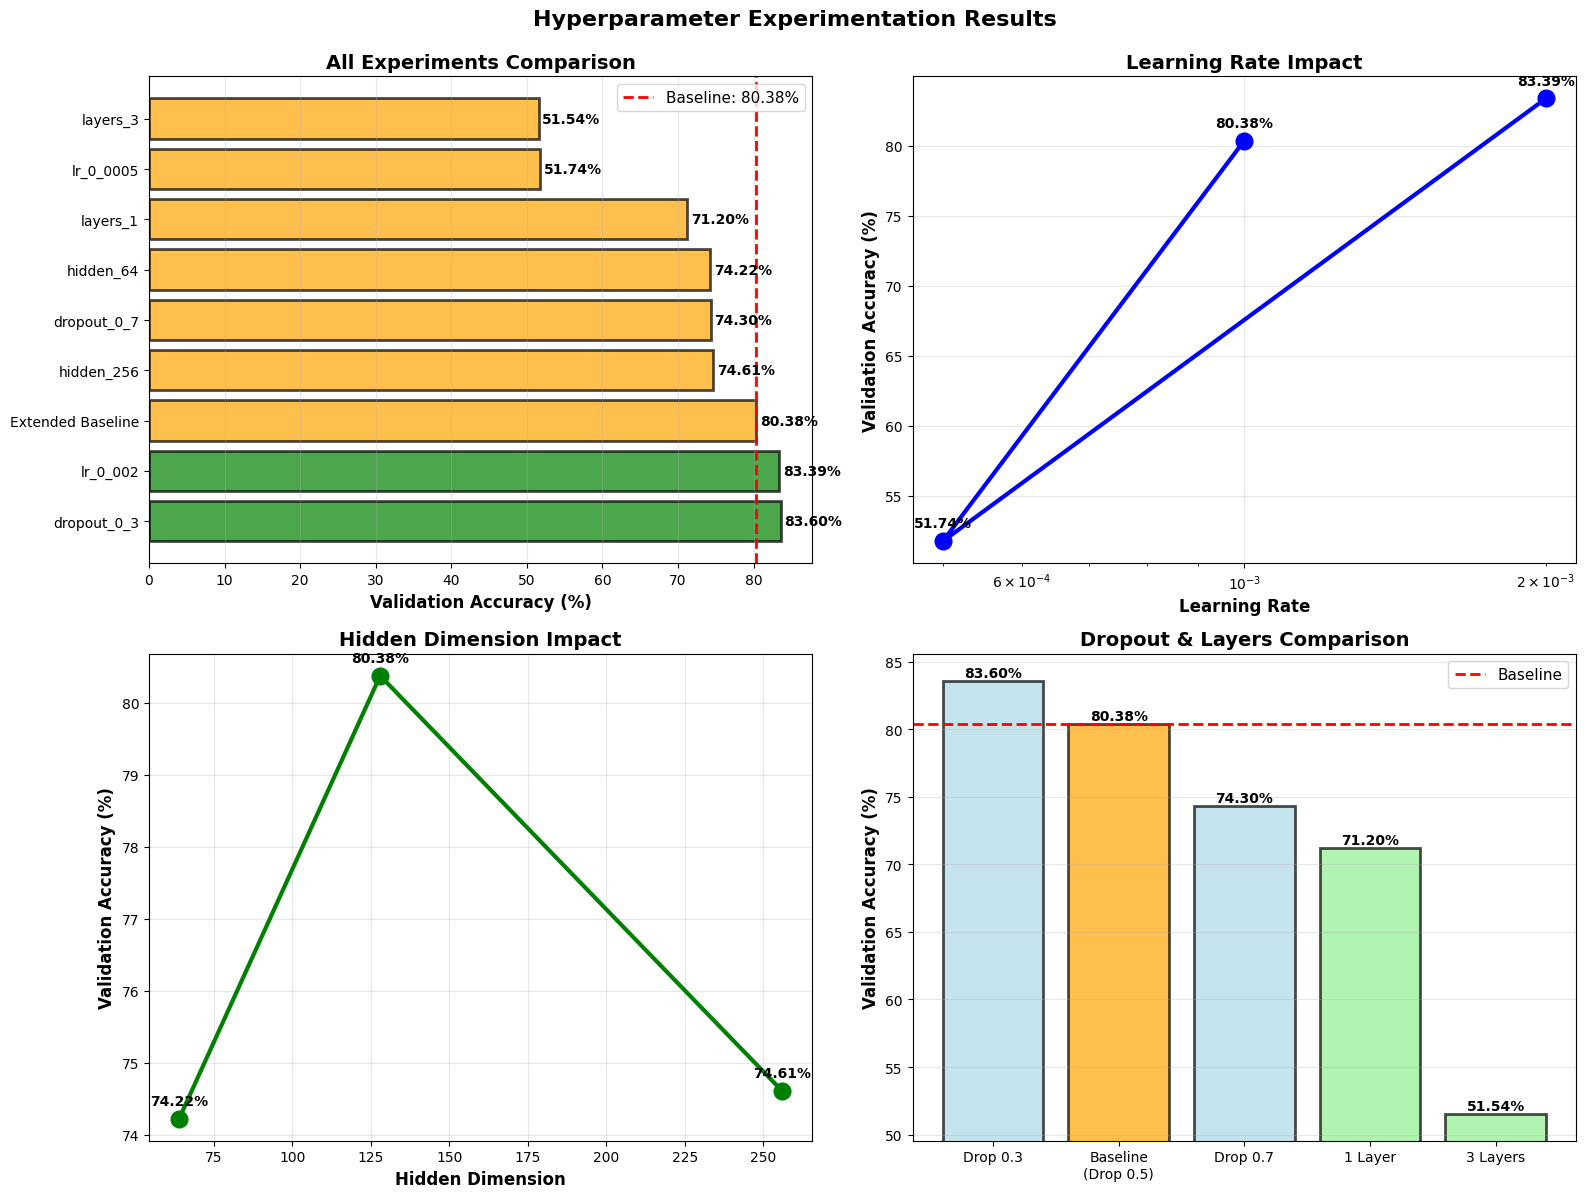


✅ Comparison visualization saved: results/day_45/hyperparameter_experiments.png

💡 KEY INSIGHTS:
Learning Rate impact: 31.65% range
Hidden Dimension impact: 6.15% range
Dropout impact: 9.30% range
Layers impact: 19.66% range

Most impactful hyperparameter:
  🏆 Learning Rate (31.65% range)

✅ All experiments saved: models/experiments/all_experiments.pkl

✅ Exercise 2.6 Complete!


In [15]:
# ==================================================
# EXERCISE 2.6: EXPERIMENT COMPARISON & ANALYSIS
# ==================================================
print("\n" + "=" * 80)
print("EXERCISE 2.6: Experiment Comparison & Analysis")
print("=" * 80)

"""
📖 THEORY: Analyzing Experiment Results

Now we compare all experiments to find:
1. Which hyperparameter had biggest impact?
2. What's the best configuration?
3. Should we combine best hyperparameters?
"""

print("\n📊 COMPLETE EXPERIMENT RESULTS")
print("=" * 80)

# Create results dataframe
results_data = []

for exp_name, exp_data in experiments.items():
    if exp_data['status'] == 'COMPLETE':
        results_data.append({
            'Experiment': exp_data['name'],
            'Val Acc (%)': exp_data['best_valid_acc'] * 100,
            'Train Acc (%)': exp_data.get('final_train_acc', 0) * 100,
            'Best Epoch': exp_data.get('best_epoch', 0),
            'Time (min)': exp_data.get('training_time', 0) / 60,
        })

results_df = pd.DataFrame(results_data)
results_df = results_df.sort_values('Val Acc (%)', ascending=False)

print("\n" + results_df.to_string(index=False))
print("\n" + "=" * 80)

# Find best experiment
best_experiment = results_df.iloc[0]
print(f"\n🏆 BEST EXPERIMENT: {best_experiment['Experiment']}")
print(f"   Validation Accuracy: {best_experiment['Val Acc (%)']:.2f}%")
print(f"   Improvement over baseline: {best_experiment['Val Acc (%)'] - best_valid_acc*100:.2f}%")
print("=" * 80)

# Visualize all experiments
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Bar chart of all experiments
exp_names = results_df['Experiment'].tolist()
val_accs = results_df['Val Acc (%)'].tolist()
colors = ['green' if acc > best_valid_acc*100 else 'orange' for acc in val_accs]

axes[0, 0].barh(exp_names, val_accs, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
axes[0, 0].axvline(x=best_valid_acc*100, color='red', linestyle='--', linewidth=2, label=f'Baseline: {best_valid_acc*100:.2f}%')
axes[0, 0].set_xlabel('Validation Accuracy (%)', fontsize=12, fontweight='bold')
axes[0, 0].set_title('All Experiments Comparison', fontsize=14, fontweight='bold')
axes[0, 0].legend(fontsize=11)
axes[0, 0].grid(True, alpha=0.3, axis='x')

# Add value labels
for i, (name, acc) in enumerate(zip(exp_names, val_accs)):
    axes[0, 0].text(acc + 0.5, i, f'{acc:.2f}%', va='center', fontsize=10, fontweight='bold')

# 2. Learning rate comparison
lr_experiments = ['baseline', 'lr_0_0005', 'lr_0_002']
lr_values = [0.001, 0.0005, 0.002]
lr_accs = [experiments[exp]['best_valid_acc']*100 for exp in lr_experiments]

axes[0, 1].plot(lr_values, lr_accs, 'o-', linewidth=3, markersize=12, color='blue')
axes[0, 1].set_xlabel('Learning Rate', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Validation Accuracy (%)', fontsize=12, fontweight='bold')
axes[0, 1].set_title('Learning Rate Impact', fontsize=14, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].set_xscale('log')

for lr, acc in zip(lr_values, lr_accs):
    axes[0, 1].annotate(f'{acc:.2f}%', (lr, acc), textcoords="offset points", 
                       xytext=(0,10), ha='center', fontsize=10, fontweight='bold')

# 3. Hidden dimension comparison
hidden_experiments = ['hidden_64', 'baseline', 'hidden_256']
hidden_values = [64, 128, 256]
hidden_accs = [experiments[exp]['best_valid_acc']*100 for exp in hidden_experiments]

axes[1, 0].plot(hidden_values, hidden_accs, 'o-', linewidth=3, markersize=12, color='green')
axes[1, 0].set_xlabel('Hidden Dimension', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Validation Accuracy (%)', fontsize=12, fontweight='bold')
axes[1, 0].set_title('Hidden Dimension Impact', fontsize=14, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

for hd, acc in zip(hidden_values, hidden_accs):
    axes[1, 0].annotate(f'{acc:.2f}%', (hd, acc), textcoords="offset points", 
                       xytext=(0,10), ha='center', fontsize=10, fontweight='bold')

# 4. Dropout and layers comparison
other_experiments = ['dropout_0_3', 'baseline', 'dropout_0_7', 'layers_1', 'layers_3']
other_names = ['Drop 0.3', 'Baseline\n(Drop 0.5)', 'Drop 0.7', '1 Layer', '3 Layers']
other_accs = [experiments[exp]['best_valid_acc']*100 for exp in other_experiments]

axes[1, 1].bar(other_names, other_accs, color=['lightblue', 'orange', 'lightblue', 'lightgreen', 'lightgreen'], 
              alpha=0.7, edgecolor='black', linewidth=2)
axes[1, 1].axhline(y=best_valid_acc*100, color='red', linestyle='--', linewidth=2, label='Baseline')
axes[1, 1].set_ylabel('Validation Accuracy (%)', fontsize=12, fontweight='bold')
axes[1, 1].set_title('Dropout & Layers Comparison', fontsize=14, fontweight='bold')
axes[1, 1].legend(fontsize=11)
axes[1, 1].grid(True, alpha=0.3, axis='y')
axes[1, 1].set_ylim(min(other_accs)-2, max(other_accs)+2)

for i, acc in enumerate(other_accs):
    axes[1, 1].text(i, acc + 0.3, f'{acc:.2f}%', ha='center', fontsize=10, fontweight='bold')

plt.suptitle('Hyperparameter Experimentation Results', fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig('results/day_45/hyperparameter_experiments.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Comparison visualization saved: results/day_45/hyperparameter_experiments.png")
print("=" * 80)

print("\n💡 KEY INSIGHTS:")
print("=" * 80)

# Analyze which had biggest impact
lr_range = max(lr_accs) - min(lr_accs)
hidden_range = max(hidden_accs) - min(hidden_accs)
dropout_range = experiments['dropout_0_7']['best_valid_acc']*100 - experiments['dropout_0_3']['best_valid_acc']*100
layers_range = experiments['layers_3']['best_valid_acc']*100 - experiments['layers_1']['best_valid_acc']*100

print(f"Learning Rate impact: {lr_range:.2f}% range")
print(f"Hidden Dimension impact: {hidden_range:.2f}% range")
print(f"Dropout impact: {abs(dropout_range):.2f}% range")
print(f"Layers impact: {abs(layers_range):.2f}% range")

print("\nMost impactful hyperparameter:")
impacts = {
    'Learning Rate': lr_range,
    'Hidden Dimension': hidden_range,
    'Dropout': abs(dropout_range),
    'Layers': abs(layers_range)
}
most_impactful = max(impacts, key=impacts.get)
print(f"  🏆 {most_impactful} ({impacts[most_impactful]:.2f}% range)")

print("=" * 80)

# Save experiment results
with open('models/experiments/all_experiments.pkl', 'wb') as f:
    pickle.dump(experiments, f)

print("\n✅ All experiments saved: models/experiments/all_experiments.pkl")
print("=" * 80)

print("\n✅ Exercise 2.6 Complete!")
print("=" * 80)

In [16]:
print("\n" + "=" * 80)
print("🚀 PART 3: ADVANCED TECHNIQUES")
print("=" * 80)


🚀 PART 3: ADVANCED TECHNIQUES


In [17]:
# ==================================================
# EXERCISE 3.1: BIDIRECTIONAL LSTM
# ==================================================
print("\n" + "=" * 80)
print("EXERCISE 3.1: Bidirectional LSTM")
print("=" * 80)

"""
📖 THEORY: Bidirectional LSTM

Standard LSTM: Processes text left → right only
"This movie was not great"
↓     ↓     ↓    ↓    ↓

Bidirectional LSTM: Processes BOTH directions
"This movie was not great"
↓     ↓     ↓    ↓    ↓     (forward)
↑     ↑     ↑    ↑    ↑     (backward)

Advantages:
- Sees future context (what comes after)
- Better understanding of negations
- "not great" - backward pass sees "not" when processing "great"
- Generally 2-3% accuracy improvement

Disadvantages:
- 2x slower (processes twice)
- 2x parameters in LSTM layer
- Not suitable for real-time generation (needs full sentence)

For sentiment analysis: PERFECT! We have full review text.
"""

print("\n🔬 TESTING BIDIRECTIONAL LSTM")
print("=" * 80)

# Best hyperparameters from Part 2 (you'll need to check your results)
# For now, let's use baseline + bidirectional
bidirectional_config = {
    'learning_rate': LEARNING_RATE,
    'hidden_dim': HIDDEN_DIM,
    'dropout': DROPOUT,
    'n_layers': N_LAYERS,
    'embedding_dim': EMBEDDING_DIM,
    'bidirectional': True,  # KEY DIFFERENCE
}

print("Configuration: Baseline + Bidirectional")
print(f"  Hidden dim: {HIDDEN_DIM}")
print(f"  Bidirectional: True")
print(f"  Note: Forward + Backward → 2x hidden states concatenated")
print("=" * 80)

# Train bidirectional model
bidirectional_result = train_experiment(
    bidirectional_config, 
    'bidirectional_baseline', 
    n_epochs=10
)

experiments['bidirectional_baseline'] = bidirectional_result

print("\n📊 BIDIRECTIONAL vs STANDARD COMPARISON:")
print("=" * 80)
print(f"Standard LSTM:      {best_valid_acc*100:.2f}%")
print(f"Bidirectional LSTM: {bidirectional_result['best_valid_acc']*100:.2f}%")
improvement = (bidirectional_result['best_valid_acc'] - best_valid_acc) * 100
print(f"Improvement:        {improvement:+.2f}%")
print("=" * 80)

print("\n✅ Exercise 3.1 Complete!")
print("=" * 80)


EXERCISE 3.1: Bidirectional LSTM

🔬 TESTING BIDIRECTIONAL LSTM
Configuration: Baseline + Bidirectional
  Hidden dim: 128
  Bidirectional: True
  Note: Forward + Backward → 2x hidden states concatenated

🔬 EXPERIMENT: bidirectional_baseline

Configuration:
  learning_rate: 0.001
  hidden_dim: 128
  dropout: 0.5
  n_layers: 2
  embedding_dim: 100
  bidirectional: True

⏱️ Training for 10 epochs...

Epoch 1/10... Train: 59.11%, Valid: 59.52% 

Epoch 2/10... Train: 56.39%, Valid: 64.51% 

Epoch 3/10... Train: 71.39%, Valid: 71.11% 

Epoch 4/10... Train: 80.80%, Valid: 81.05% 

Epoch 5/10... Train: 85.94%, Valid: 83.03% 

Epoch 6/10... Train: 88.52%, Valid: 83.88% 

Epoch 7/10... Train: 90.21%, Valid: 82.46% 

Epoch 8/10... Train: 92.28%, Valid: 84.02% 

Epoch 9/10... Train: 93.61%, Valid: 83.97% 

Epoch 10/10... Train: 94.65%, Valid: 84.59% 

✅ EXPERIMENT COMPLETE: bidirectional_baseline
Best Validation Accuracy: 84.59% (epoch 10)
Final Train Accuracy: 94.65%
Training Time: 33m 20s
🎉 BEAT